ESERCIZIO

Diagnosticare il comportamento di una SimpleRNN variando la velocità di apprendimento.

- Crea una rete con un layer SimpleRNN da 64 unità
- Esegui due addestramenti separati variando il learning_rate dell'ottimizzatore Adam:
    - Test A: imposta un tasso molto alto (es. 10)
    - Test B: imposta una tasso estremamente basso (es. 1e-7)
Usa matplotlib per plottare la loss di entrambi i test.
Domanda: in quale caso la loss diventa 'NaN' o oscilla violentemente? in quale caso la curva rimane quasi piatta?

>>> Generazione dati in corso...

>>> TEST A: Avvio Training con Learning Rate = 1.0 (Molto Alto)
>>> TEST B: Avvio Training con Learning Rate = 1e-7 (Estremamente Basso)


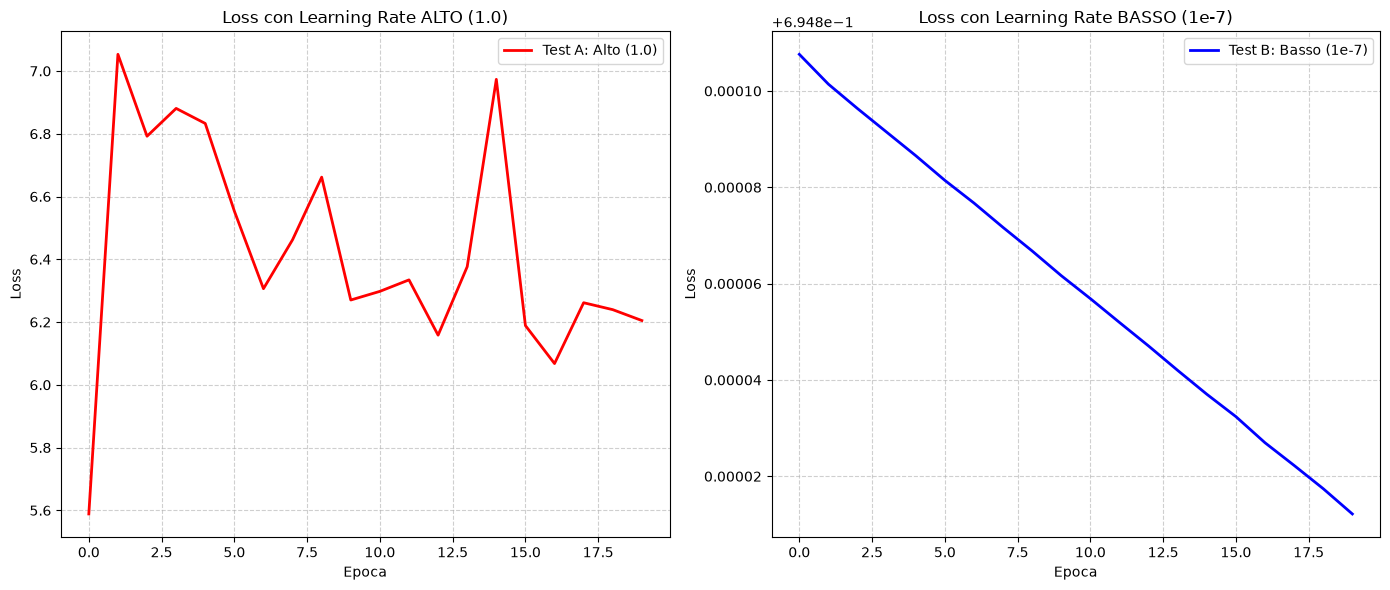


DIAGNOSI FINALE:
1. In quale caso la loss diventa 'NaN' o oscilla violentemente?
   RISPOSTA: Nel TEST A (LR = 1.0). Il passo è così grande che il modello 
   'salta' oltre il minimo, esplode matematicamente e genera NaN o oscillazioni folli.

2. In quale caso la curva rimane quasi piatta?
   RISPOSTA: Nel TEST B (LR = 1e-7). Il passo è così infinitesimale che il modello
   impiegherebbe millenni per scendere nella valle dell'errore. Non impara nulla.


In [1]:
import os

# --- 1. CONFIGURAZIONE DEL BACKEND ---
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

# --- 2. GENERAZIONE DATI (Come da esempio precedente) ---
def generate_dummy_data(num_samples=1000, max_len=20):
    x = np.random.randint(1, 100, size=(num_samples, max_len))
    y = (np.sum(x, axis=1) % 2 == 0).astype(int)
    split = int(num_samples * 0.8)
    return (x[:split], y[:split]), (x[split:], y[split:])

# --- 3. COSTRUZIONE DEL MODELLO PARAMETRIZZATA ---
def build_rnn_model_diagnostic(max_len, vocab_size, lr, rnn_units=64):
    """
    Costruisce la RNN permettendo di variare il learning rate.
    """
    inputs = layers.Input(shape=(max_len,))
    embedding = layers.Embedding(input_dim=vocab_size, output_dim=32)(inputs)
    
    # SimpleRNN da 64 unità come richiesto
    rnn_output = layers.SimpleRNN(units=rnn_units, 
                                  activation="tanh", 
                                  return_sequences=False)(embedding)
    
    outputs = layers.Dense(1, activation="sigmoid")(rnn_output)
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Utilizziamo l'ottimizzatore Adam con il learning rate passato come argomento
    # NOTA: Rimuoviamo il clipnorm per esasperare gli effetti del learning rate alto
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

# --- 4. ESECUZIONE DEI TEST ---
MAX_LEN = 20
VOCAB_SIZE = 100
EPOCHS = 20 # Bastano poche epoche per vedere la differenza drastica

print(">>> Generazione dati in corso...")
(x_train, y_train), (x_val, y_val) = generate_dummy_data(max_len=MAX_LEN)

# --- TEST A: Learning Rate Altissimo (1.0) ---
print("\n>>> TEST A: Avvio Training con Learning Rate = 1.0 (Molto Alto)")
model_a = build_rnn_model_diagnostic(MAX_LEN, VOCAB_SIZE, lr=1.0)
history_a = model_a.fit(x_train, y_train, epochs=EPOCHS, batch_size=32, verbose=0)

# --- TEST B: Learning Rate Bassissimo (1e-7) ---
print(">>> TEST B: Avvio Training con Learning Rate = 1e-7 (Estremamente Basso)")
model_b = build_rnn_model_diagnostic(MAX_LEN, VOCAB_SIZE, lr=1e-7)
history_b = model_b.fit(x_train, y_train, epochs=EPOCHS, batch_size=32, verbose=0)

# --- 5. PLOT DEI RISULTATI ---
plt.figure(figsize=(14, 6))

# Subplot Errore (Loss)
plt.subplot(1, 2, 1)
plt.plot(history_a.history['loss'], label='Test A: Alto (1.0)', color='red', linewidth=2)
plt.title('Loss con Learning Rate ALTO (1.0)')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_b.history['loss'], label='Test B: Basso (1e-7)', color='blue', linewidth=2)
plt.title('Loss con Learning Rate BASSO (1e-7)')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# --- RISPOSTA ALLE DOMANDE ---
print("\n" + "="*50)
print("DIAGNOSI FINALE:")
print("="*50)
print("1. In quale caso la loss diventa 'NaN' o oscilla violentemente?")
print("   RISPOSTA: Nel TEST A (LR = 1.0). Il passo è così grande che il modello ")
print("   'salta' oltre il minimo, esplode matematicamente e genera NaN o oscillazioni folli.")
print("\n2. In quale caso la curva rimane quasi piatta?")
print("   RISPOSTA: Nel TEST B (LR = 1e-7). Il passo è così infinitesimale che il modello")
print("   impiegherebbe millenni per scendere nella valle dell'errore. Non impara nulla.")
print("="*50)

Con learning rate 1.0 il modello presenta forti oscillazioni della loss, segnale che gli aggiornamenti dei pesi sono eccessivi e l'ottimizzatore non riesce a convergere stabilmente. Con learning rate 1e-7 la loss diminuisce in maniera stabile, ma la variazione è estremamente piccola: gli aggiornamenti sono troppo ridotti e l'apprendimento risulta molto lento. È quindi opportuno scegliere un learning rate intermedio.